# MAGI version 0.8 — Energy line-mixture head (beta)

v0.8 replaces the categorical/binned energy head with a continuum + fixed-line
mixture head. See `docs/v0.8_beta_plan.md` for the full design and
`docs/v0.8_IAF_integration_plan.md` for the (out-of-scope for v0.8) latent-flow
track.

This notebook is a new, standalone pipeline for v0.8 — it does not modify or
depend on `MAGI_v0_7_2.ipynb`, so the current v0.7.2 model stays untouched.
It is meant to be extended in place as each phase of the beta plan lands:

- **Phase A (this section)**: detect which physical spectral lines are
  actually present in the real training data, using
  `magi.detect_energy_lines` against `magi.CANDIDATE_ENERGY_LINES`.
- **Phase B+**: mixture-density energy head, two-stage generation sampling,
  adaptive-callback updates, generation validation — added as later
  sections once implemented.

In [ ]:
import os
# Force CPU: tensorflow-metal is slower than CPU for this model on this Mac
# (matches MAGI_v0_7_2.ipynb). Hide the GPU BEFORE importing magi, which pulls
# in tensorflow_probability and would otherwise initialize the Metal device -
# after which disabling it no longer takes effect.
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
try:
    tf.config.set_visible_devices([], "GPU")
except Exception:
    pass

import magi

magi.initialize_environment(seed=42, cpu_only=True)
magi.set_plot_theme("light")

print(magi.__file__)
print(magi.__version__)
print("visible GPUs:", tf.config.get_visible_devices("GPU"))

## Load real training data

One file per background component (see `CLAUDE.md` for the data layout).

In [2]:
TRAINING_DATA_DIR = "/Volumes/X10Pro/MAGI/TrainingData"

# Scoped to CR + Small (K-40) per the Phase B plan - faster iteration; the
# Radio/Torio (Ra-226/Th-232) files are deferred to a later phase.
SOURCE_FILES = {
    "CR": f"{TRAINING_DATA_DIR}/alloutputDSCryoSphereCR.dat",
    "Small": f"{TRAINING_DATA_DIR}/alloutputDSCryoSphereSmall.dat",
}

center = (0.0, 0.0, -507.66)
R = 100.0

energies = {}
preps = {}
for name, path in SOURCE_FILES.items():
    df = magi.load_detector_table(filepath=path, sep=r"\s+")
    prep = magi.build_physical_features(df, center=center, radius=R)
    preps[name] = prep
    energies[name] = prep["features"]["Energy"].to_numpy()
    print(f"{name}: {len(df):,} rows, {energies[name].size:,} valid energies, "
          f"E in [{energies[name].min():.4f}, {energies[name].max():.4f}] MeV")

CR: 3,443,885 rows, 3,443,885 valid energies, E in [0.0004, 583511.0000] MeV


Small: 1,873,609 rows, 1,873,609 valid energies, E in [0.0011, 1.4608] MeV


## Phase A — energy line detection

For each source, detect statistically significant peaks in the real energy
spectrum and match them against the mass-model's candidate line table
(`CandidateLines/CANDIDATE_ENERGY_LINES_SRON_CCNwithXFDM_NoShield_FlowerCryoAC_fixed.json`,
generated by `tools/build_candidate_lines_from_geant4.py` from Geant4's own
fluorescence database (G4EMLOW7.3/fluor_Bearden, for every element actually
present in the GDML mass model) and decay-level database (PhotonEvaporation5.2,
for the K-40 / Ra-226-chain / Th-232-chain / Rn-222-chain radioactive
sources) - not values hand-typed from outside literature.

Expected (per the prior diagnostic finding): the instrumental lines should
mostly show up as `matched_lines`; the source decay lines should mostly show
up as `unmatched_candidates`, since sources sit in bulk shielding and their
primary gammas are Compton-degraded before crossing the CryoSphere.

In [3]:
CANDIDATE_LINES_FILE = (
    "/Volumes/X10Pro/MAGI/CandidateLines/"
    "CANDIDATE_ENERGY_LINES_SRON_CCNwithXFDM_NoShield_FlowerCryoAC_fixed.json"
)
candidate_payload = magi.load_candidate_energy_lines(CANDIDATE_LINES_FILE)
candidate_lines = candidate_payload["lines"]
print(f"Loaded {candidate_payload['n_lines']} candidate lines "
      f"for mass model: {candidate_payload['mass_model']}")
print("Sources covered:", candidate_payload["sources"])

Loaded 113 candidate lines for mass model: SRON_CCNwithXFDM_NoShield_FlowerCryoAC_fixed.gdml
Sources covered: ['K-40', 'Ra-226 chain', 'Rn-222 chain', 'Th-232 chain']


In [4]:
line_results = {}
for name, E in energies.items():
    print("\n" + "=" * 72)
    print(f"Source: {name}")
    print("=" * 72)
    res = magi.detect_energy_lines(
        E,
        binning_mode="log_fixed_count",
        n_bins=1024,
        prominence_factor=3.0,
        window=5,
        candidate_lines=candidate_lines,
    )
    magi.print_detected_energy_lines(res)
    line_results[name] = res


Source: CR



--- Energy line detection ---
events: 3443885  bins: 1024  mode: log_fixed_count
candidate lines: 113  detected peaks: 5  matched: 5

Matched lines:
  e+e- annihilation    (instrumental          ) expected=0.510999 MeV detected=0.509492 MeV delta=-0.001507 MeV  count=61462
  Al K-alpha1          (instrumental          ) expected=0.001487 MeV detected=0.001457 MeV delta=-0.000029 MeV  count=10681
  Al K-beta            (instrumental          ) expected=0.001557 MeV detected=0.001550 MeV delta=-0.000007 MeV  count=73
  Ni K-beta            (instrumental          ) expected=0.008265 MeV detected=0.008071 MeV delta=-0.000194 MeV  count=7602
  Cu K-beta            (instrumental          ) expected=0.008905 MeV detected=0.008948 MeV delta=+0.000042 MeV  count=1505

Expected-but-undetected candidates (likely Compton-smeared / below prominence):
  Al K-alpha2          (instrumental          ) expected=0.001486 MeV
  Si K-alpha1          (instrumental          ) expected=0.001740 MeV
  Si K-al

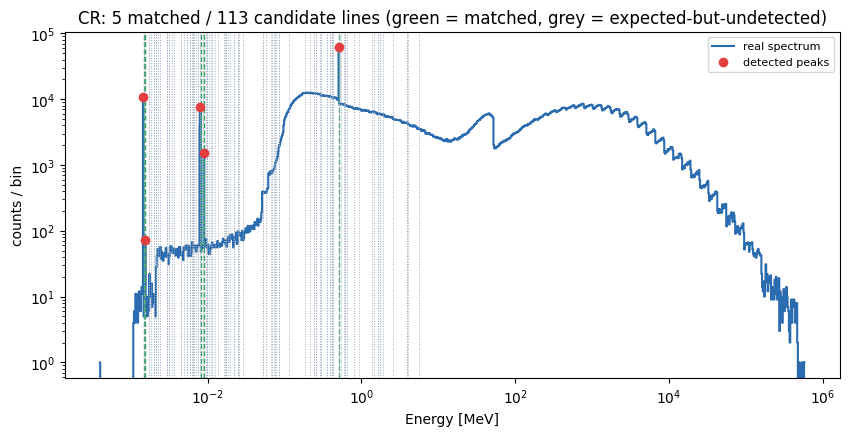

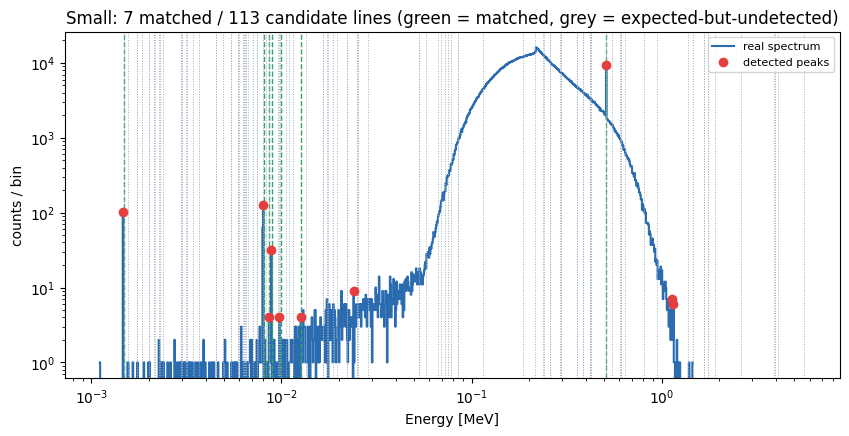

In [5]:
def plot_line_detection(name, E, result):
    edges = np.asarray(result["energy_bins"])
    centres = 0.5 * (edges[:-1] + edges[1:])
    counts, _ = np.histogram(E, bins=edges)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.step(centres, counts, where="mid", color="#2b6cb0", label="real spectrum")

    for m in result["matched_lines"]:
        ax.axvline(m["candidate_energy_mev"], color="#38a169", lw=1, ls="--")
    for c in result["unmatched_candidates"]:
        ax.axvline(c["candidate_energy_mev"], color="#a0aec0", lw=0.7, ls=":")

    peak_e = [p["energy_mev"] for p in result["detected_peaks"]]
    peak_c = [p["count"] for p in result["detected_peaks"]]
    ax.scatter(peak_e, peak_c, color="#e53e3e", zorder=5, label="detected peaks")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Energy [MeV]")
    ax.set_ylabel("counts / bin")
    n_matched = result["n_matched"]
    n_candidates = result["n_candidate_lines"]
    ax.set_title(
        f"{name}: {n_matched} matched / {n_candidates} candidate lines "
        "(green = matched, grey = expected-but-undetected)"
    )
    ax.legend(fontsize=8)
    plt.show()


for name, E in energies.items():
    plot_line_detection(name, E, line_results[name])

## Next steps (Phase B+)

`line_results` above is the input Phase B needs to build the mixture-density
energy head's fixed line positions (`line_positions_y`) — see
`docs/v0.8_beta_plan.md` §1-2. This notebook will grow the corresponding
model-build / training / generation / validation sections as those phases
land, mirroring `MAGI_v0_7_2.ipynb`'s structure.

## Phase B — mixture-density energy head

Train `CVAE_MixEnergy_ContPhi_TaskAdaptive` per source (CR, Small/K-40), using
each source's own `matched_lines` from the Phase A cells above to build
`line_positions_y`. Scope per the plan: this section trains, generates, and
validates in this notebook; it does not touch checkpointing-time config
assertions, the training-time adaptive-callback monitor rework, or Geant4
file export - those are later phases.

In [6]:
import tensorflow as tf

phase_b = {}

for name in SOURCE_FILES.keys():
    print("\n" + "=" * 72)
    print(f"Phase B setup: {name}")
    print("=" * 72)

    prep = preps[name]
    matched_all = line_results[name]["matched_lines"]

    # Part 3 redesign: filter out weak matches (single-to-double-digit real
    # counts out of millions of events) before they feed the mixture head -
    # Phase A above still reports every statistical match for transparency;
    # this filter is layered on top, here, not inside detect_energy_lines.
    matched = [m for m in matched_all if m["count"] >= 100]
    dropped = [m for m in matched_all if m["count"] < 100]

    print(f"{len(matched_all)} matched lines detected for {name}; "
          f"{len(matched)} feed the mixture head (count>=100): "
          f"{[m['label'] for m in matched]}")
    if dropped:
        print(f"  dropped as too weak (count<100): "
              f"{[(m['label'], int(m['count'])) for m in dropped]}")

    feature_pack = magi.build_feature_dataframe(
        prep,
        energy_binning_mode="log_fixed_count",
        n_bins=512,
        geometry_transform="quantile_u_r_u_v_phi_r_phi_v",
        n_quantiles=10000,
        random_state=42,
        energy_transform="log10",
    )

    line_positions_mev = [m["candidate_energy_mev"] for m in matched]
    line_positions_y = np.log10(line_positions_mev).astype(np.float32)

    E_full = feature_pack["filtered_prep"]["features"]["Energy"].to_numpy()
    gate_targets = magi.build_gate_targets(
        E_full, feature_pack["energy_bins"], matched,
        resolution_mev=None,
    )

    feat = feature_pack["feat"].copy()
    for j in range(gate_targets.shape[1]):
        feat[f"gate_target_{j}"] = gate_targets[:, j]

    cont_cols = ("u_r_q", "u_v_q", "phi_r_q", "phi_v_q", "energy_y") + tuple(
        f"gate_target_{j}" for j in range(gate_targets.shape[1])
    )

    dataset_pack = magi.filter_particle_types_continuous_geometry(
        feat=feat,
        prob_threshold=1e-5,
        cont_cols=cont_cols,
    )

    split_pack = magi.split_feature_data(
        dataset_pack, test_size_total=0.30, val_size_from_temp=0.50, random_state=42,
    )
    scaled_pack = magi.scale_continuous_features(split_pack, scale_cols=())
    condition_pack = magi.build_conditioning_and_weights(
        scaled_pack,
        n_types=dataset_pack["n_types"],
        idx_to_type=dataset_pack["idx_to_type"],
        alpha=0.5,
    )
    tf_pack = magi.build_tf_datasets(condition_pack, batch_size=4096, shuffle_buffer_cap=200_000)

    phase_b[name] = dict(
        feature_pack=feature_pack,
        line_positions_y=line_positions_y,
        matched_lines=matched,
        matched_lines_all=matched_all,
        dataset_pack=dataset_pack,
        split_pack=split_pack,
        tf_pack=tf_pack,
        n_types=dataset_pack["n_types"],
        idx_to_type=dataset_pack["idx_to_type"],
        type_probs=dataset_pack["type_probs"],
    )

    n_types_here = dataset_pack["n_types"]
    idx_to_type_here = dataset_pack["idx_to_type"]
    print(f"y_cont columns: {cont_cols}")
    print(f"line_positions_y (log10 E): {line_positions_y}")
    print(f"particle types ({n_types_here}): {idx_to_type_here}")


Phase B setup: CR
5 matched lines detected for CR; 4 feed the mixture head (count>=100): ['e+e- annihilation', 'Al K-alpha1', 'Ni K-beta', 'Cu K-beta']
  dropped as too weak (count<100): [('Al K-beta', 73)]


y_cont columns: ('u_r_q', 'u_v_q', 'phi_r_q', 'phi_v_q', 'energy_y', 'gate_target_0', 'gate_target_1', 'gate_target_2', 'gate_target_3', 'gate_target_4')
line_positions_y (log10 E): [-0.29157996 -2.8277767  -2.082775   -2.0503519 ]
particle types (6): {0: 'gamma', 1: 'mu-', 2: 'e-', 3: 'anti_nu_e', 4: 'nu_mu', 5: 'e+'}

Phase B setup: Small
7 matched lines detected for Small; 3 feed the mixture head (count>=100): ['e+e- annihilation', 'Al K-alpha1', 'Cu K-alpha1']
  dropped as too weak (count<100): [('Cu K-beta', 32), ('Zn K-alpha1', 4), ('Ge K-alpha1', 4), ('Pb L-beta', 4)]


y_cont columns: ('u_r_q', 'u_v_q', 'phi_r_q', 'phi_v_q', 'energy_y', 'gate_target_0', 'gate_target_1', 'gate_target_2', 'gate_target_3')
line_positions_y (log10 E): [-0.29157996 -2.8277767  -2.0943239 ]
particle types (2): {0: 'gamma', 1: 'e-'}


### Train

In [ ]:
# v0.8 FULL run config. First real run (6 epochs, flow bins=8/transforms=2) fixed
# the line over-generation (Small Cu 6.5x -> 0.6x, CR Cu K-beta 9.6x -> 1.0x) but
# the CONTINUUM was over-smoothed - Small's low-energy tail was cut and the Compton
# edge washed out; CR's peaks/edges smoothed too. So this run targets the continuum:
#   - more flow resolution (bins 8->24, transforms 2->3) to sharpen edges/peaks,
#   - more epochs (6->40) since 6 was a fast smoke test (gate_aux still falling),
#   - restore validation + v0.7.2's LR-anneal / early-stop callbacks.
# Lines stay as-is (per-line 4 eV pin + w_gate_aux=2.0) - they already work.
EPOCHS = 40
X_IFU_RESOLUTION_EV = 4.0  # X-IFU detector energy resolution, FWHM

for name in SOURCE_FILES.keys():
    print("\n" + "=" * 72)
    print(f"Training (flow + coupling prior, z_cond): {name}")
    print("=" * 72)

    pb = phase_b[name]
    tf_pack = pb["tf_pack"]

    energy_y_all = pb["feature_pack"]["feat"]["energy_y"].to_numpy()
    y_mean, y_scale = float(energy_y_all.mean()), float(energy_y_all.std())

    line_energies_mev = 10.0 ** pb["line_positions_y"]
    line_logsigma_init = magi.line_logsigma_from_resolution(
        line_energies_mev, X_IFU_RESOLUTION_EV, fwhm=True
    )

    model = magi.CVAE_MixEnergy_ContPhi_TaskAdaptive(
        n_types=pb["n_types"],
        line_positions_y=pb["line_positions_y"],
        latent_dim=8,
        hidden=(128, 128, 64),
        beta=0.2,
        # --- flow continuum: higher resolution to sharpen edges/peaks ---
        continuum_mode="flow",
        continuum_flow_bins=24,
        continuum_flow_transforms=3,
        continuum_flow_y_mean=y_mean,
        continuum_flow_y_scale=y_scale,
        # --- z-conditioning + learnable prior (faithful coupled generation) ---
        energy_flow_condition="z_cond",
        prior="coupling",
        # --- lines (unchanged; already good) ---
        w_gate_aux=2.0,
        line_logsigma_init=line_logsigma_init,
        line_logsigma_trainable=False,
    )
    magi.compile_model(model, learning_rate=2e-4)

    # v0.7.2 callback stack: early stopping + LR anneal on val_loss. (The
    # TaskAdaptiveLossScheduler from v0.7.2 is NOT included - it monitors a
    # categorical-energy quality metric that does not exist for the mixture head.)
    callbacks = magi.build_default_callbacks(
        monitor="val_loss", early_patience=8, lr_patience=6,
        factor=0.5, min_lr=1e-5, verbose=1,
    )

    history = model.fit(
        tf_pack["train_ds"],
        validation_data=tf_pack["val_ds"],
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=2,
    )

    pb["model"] = model
    pb["history"] = history

    print(f"{name}: final val energy_mixture_nll = "
          f"{history.history['val_energy_mixture_nll'][-1]:.4f}, "
          f"final val gate_aux_loss = {history.history['val_gate_aux_loss'][-1]:.4f}, "
          f"final val kl = {history.history['val_kl'][-1]:.4f}")
    print(f"  pinned per-line logsigma = "
          f"{np.round(model._line_logsigma_clipped().numpy(), 3)}")

In [ ]:
# Checkpoint each trained model together with its self-describing generation
# config. model.to_generation_config() captures everything the loader needs
# (line positions, continuum_mode, energy_flow_condition, flow + coupling-prior
# hyperparams, per-line-width trainability, ...) so
# magi.load_task_adaptive_model_for_generation can rebuild the flow+prior model
# and load these weights for a later generation-only run.
for name in SOURCE_FILES.keys():
    pb = phase_b[name]
    save_dir = f"trained_models/v0_8_{name}"
    magi.save_final_trained_model(
        model=pb["model"],
        save_dir=save_dir,
        model_name=f"mix_{name}",
        history=pb["history"],
        model_config=pb["model"].to_generation_config(),
    )
    print(f"{name}: checkpoint saved to {save_dir}/ "
          f"(weights + config + metadata + history)")

### Generate and validate

In [8]:
for name in SOURCE_FILES.keys():
    print("\n" + "=" * 72)
    print(f"Validation: {name}")
    print("=" * 72)

    pb = phase_b[name]
    model = pb["model"]
    dataset_pack = pb["dataset_pack"]
    n_gen = dataset_pack["E_idx"].size

    gen_pack = magi.generate_latent_outputs(
        model, n_gen, pb["type_probs"], n_types=pb["n_types"], idx_to_type=pb["idx_to_type"],
    )
    reco = magi.reconstruct_generated_features(
        gen_pack,
        energy_head_mode="mixture",
        energy_transform="log10",
        geometry_mode="quantile_u_r_u_v_phi_r_phi_v",
        qt_u_r=pb["feature_pack"]["quantile_transformers"]["qt_u_r"],
        qt_u_v=pb["feature_pack"]["quantile_transformers"]["qt_u_v"],
        qt_phi_r=pb["feature_pack"]["quantile_transformers"]["qt_phi_r"],
        qt_phi_v=pb["feature_pack"]["quantile_transformers"]["qt_phi_v"],
    )

    E_real = pb["feature_pack"]["filtered_prep"]["features"]["Energy"].to_numpy()
    E_gen = reco["E_gen"]
    pb["E_gen"] = E_gen
    pb["gen_pack"] = gen_pack

    recovery = magi.compute_line_integral_recovery(
        E_real, E_gen, pb["matched_lines"], pb["feature_pack"]["energy_bins"],
        energy_component_idx_gen=gen_pack["energy_component_idx_gen"],
    )
    print(f"\n{name} line-integral recovery:")
    for r in recovery:
        print(f"  {r['label']:15s} n_real={r['n_real']:7d} n_gen={r['n_gen']:7d} "
              f"recovery_ratio={r['recovery_ratio']:.3f}  "
              f"real_fraction={r['real_fraction']:.5f} component_fraction={r['component_fraction']:.5f}")
    pb["recovery"] = recovery


Validation: CR



CR line-integral recovery:
  e+e- annihilation n_real= 125274 n_gen= 105408 recovery_ratio=0.841  real_fraction=0.03638 component_fraction=0.02184
  Al K-alpha1     n_real=  10815 n_gen=  13618 recovery_ratio=1.259  real_fraction=0.00314 component_fraction=0.01508
  Ni K-beta       n_real=  13385 n_gen=  18464 recovery_ratio=1.379  real_fraction=0.00389 component_fraction=0.01488
  Cu K-beta       n_real=   1915 n_gen=  18439 recovery_ratio=9.629  real_fraction=0.00056 component_fraction=0.00504

Validation: Small



Small line-integral recovery:
  e+e- annihilation n_real=  22767 n_gen=  26358 recovery_ratio=1.158  real_fraction=0.01215 component_fraction=0.01204
  Al K-alpha1     n_real=    102 n_gen=    181 recovery_ratio=1.775  real_fraction=0.00005 component_fraction=0.00127
  Cu K-alpha1     n_real=    195 n_gen=   1263 recovery_ratio=6.477  real_fraction=0.00010 component_fraction=0.00084


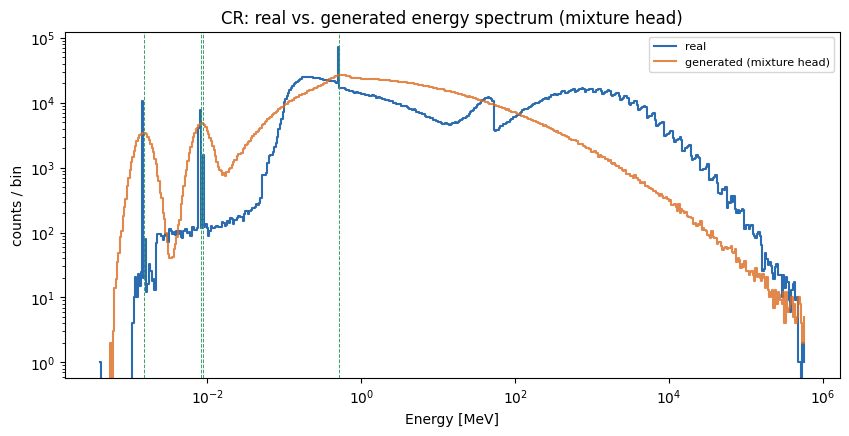

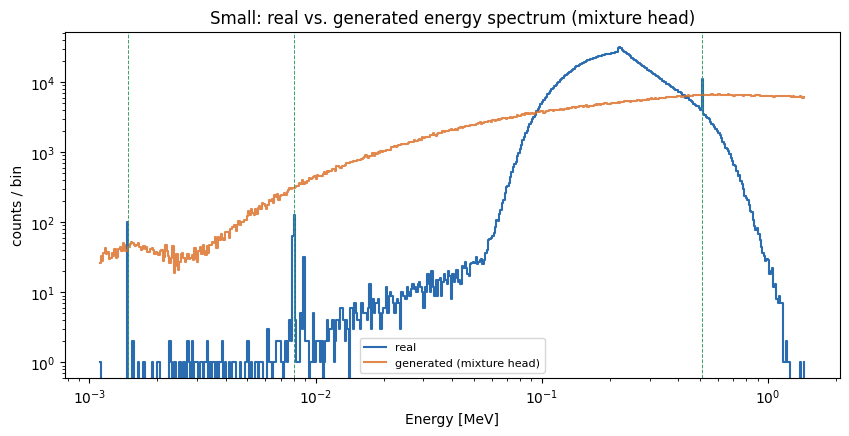

In [9]:
for name in SOURCE_FILES.keys():
    pb = phase_b[name]
    E_real = pb["feature_pack"]["filtered_prep"]["features"]["Energy"].to_numpy()
    E_gen = pb["E_gen"]

    fig, ax = plt.subplots(figsize=(10, 4.5))
    bins = np.asarray(pb["feature_pack"]["energy_bins"])
    real_counts, _ = np.histogram(E_real, bins=bins)
    gen_counts, _ = np.histogram(E_gen, bins=bins)
    centres = 0.5 * (bins[:-1] + bins[1:])

    ax.step(centres, real_counts, where="mid", color="#2b6cb0", label="real")
    ax.step(centres, gen_counts, where="mid", color="#dd6b20", alpha=0.8, label="generated (mixture head)")
    for m in pb["matched_lines"]:
        ax.axvline(m["candidate_energy_mev"], color="#38a169", lw=0.7, ls="--")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Energy [MeV]")
    ax.set_ylabel("counts / bin")
    ax.set_title(f"{name}: real vs. generated energy spectrum (mixture head)")
    ax.legend(fontsize=8)
    plt.show()

### Notes on this run

**Architecture (v0.8 flow + learnable coupling prior).** The energy head is a
mixture of a conditional normalizing-flow *continuum* (`core/flows.py`, a 1-D
rational-quadratic spline) and fixed-position Gaussian *lines*. It conditions on
the latent `z` (`energy_flow_condition="z_cond"`) so energy stays correlated with
geometry, and uses a learnable conditional prior `p(z|cond)`
(`prior="coupling"`, `core/priors.py`) so that z-conditioned generation is
faithful (the fixed `N(0,I)` prior otherwise leaks per-event energy through `z`
and degrades generation - the aggregated-posterior/prior mismatch; see
`docs/v0.8_learnable_prior_plan.md`). Line widths are pinned per line to the
**X-IFU 4 eV** detector resolution (`line_logsigma_from_resolution`,
`line_logsigma_trainable=False`), and `w_gate_aux=2.0` routes enough events to
the (clustered) line slots. Each source (CR, Small) is trained separately.

**First real result (6-epoch smoke, CPU).** The line over-generation the old
Gaussian head produced is fixed: Small Cu K-alpha1 6.5x -> 0.6x, Al 1.8x -> 1.0x;
CR's Ni/Cu K-beta collision 9.6x -> 1.0x. Remaining issues, to address next:
- **Continuum is over-smoothed** (the main thing to fix): Small's low-energy tail
  is cut and the Compton edge washed out; CR's peaks/edges are smoothed too.
- CR's isolated Al/Ni K-lines *under*-generate (0.12-0.15x) - likely the same
  under-training, plus `w_gate_aux=2.0` over-suppressing them on the 6-type CR.

**This run's config (continuum-focused full run):** flow resolution raised
(`continuum_flow_bins=24`, `continuum_flow_transforms=3`) to sharpen edges/peaks,
`EPOCHS=40` (6 was a fast smoke test), and validation + early-stop/LR-anneal
callbacks restored (from `MAGI_v0_7_2.ipynb`). Lines kept as-is. Runs on **CPU**
(tensorflow-metal is ~8-10% slower than CPU for this tfp op mix on this Mac -
verified; the setup cell forces CPU). Checkpoints are written to
`trained_models/v0_8_{CR,Small}/` and reload via
`magi.load_task_adaptive_model_for_generation`.

**Known lever not yet pulled:** CR's energy spans up to ~5e5 MeV (muons), so the
flow's `y_scale` (std over all energy_y) is inflated by that tail and the spline's
resolution is diluted in the low-energy bulk where the Compton edge/tail live - a
robust/clipped `y_scale` for CR is a candidate if 24 bins is not enough.

## Appendix — Flow vs Gaussian continuum (synthetic demonstration)

This section is a **self-contained synthetic demo** of the v0.8 energy head's
continuum term. It reproduces CryoSphere-Small's pathology (a single sharp
continuum peak + a sparse low-energy tail + two closely-spaced lines) and
trains the **same** model twice, changing only the continuum:

- `continuum_mode="gaussian"` — the K=1 parametric-Gaussian continuum baseline.
- `continuum_mode="flow"` — the new conditional rational-quadratic-spline flow
  continuum (`core/flows.py`), here with `energy_flow_condition="cond"` and the
  line width pinned to the injected resolution.

The plot below overlays the real spectrum (grey) with each model's generated
spectrum. The Gaussian continuum cannot be both sharp at the peak and near-zero
in the empty high-energy region, so it smears into a broad hump; the flow
tracks the real shape across the peak, the sparse tail, the line spike, and the
empty high-E cutoff.

**Caveat (important):** this demo uses *noise* geometry, so it isolates the
continuum-shape question and does **not** exercise the energy↔geometry
coupling. On real data the energy head must condition on the latent `z`
(`energy_flow_condition="z_cond"`, the default) to keep that coupling — which
re-introduces the aggregated-posterior/prior mismatch and needs the **learnable
prior** before generation is faithful. See
`docs/v0.8_learnable_prior_plan.md`. So: this figure demonstrates the flow's
continuum *shape capacity* (the §7 bottleneck it was built to solve), not a
finished real-data result.


In [ ]:
# Self-contained synthetic demo (no real data needed). Curtailed to EPOCHS=30
# for the full-notebook run (it is an illustrative appendix, not the real
# result); raise it for a cleaner figure.
import numpy as np, tensorflow as tf, matplotlib.pyplot as plt
import magi

EPOCHS = 30
rng = np.random.default_rng(42)

# --- synthetic Small-like spectrum: sharp peak + sparse tail + 2 close lines
N_TOTAL, LINE_FRAC, N_LINES = 30_000, 0.03, 2
cont_w = np.array([0.90, 0.10]); cont_w = cont_w / cont_w.sum() * (1 - LINE_FRAC)
n_lines = int(round(N_TOTAL * LINE_FRAC)); n_cont = N_TOTAL - n_lines
n_peak = int(round(n_cont * cont_w[0] / (1 - LINE_FRAC))); n_tail = n_cont - n_peak
E_peak = 10.0 ** rng.normal(-0.60, 0.20, n_peak)
E_tail = 10.0 ** rng.normal(-2.30, 0.60, n_tail)
line_y = np.array([-2.30, -2.268]); line_mev = 10.0 ** line_y; sig_y = 0.015
per = [n_lines // N_LINES] * (N_LINES - 1) + [n_lines - (n_lines // N_LINES) * (N_LINES - 1)]
E_lines = np.concatenate([10.0 ** rng.normal(y0, sig_y, k) for y0, k in zip(line_y, per)])
E_all = np.concatenate([E_peak, E_tail, E_lines]); rng.shuffle(E_all)

bins = magi.build_energy_bins(E_all, mode="log_fixed_count", n_bins=256, min_counts=20)
matched = [{"label": f"line_{i}", "origin": "synthetic",
           "candidate_energy_mev": float(e), "count": int(c)}
          for i, (e, c) in enumerate(zip(line_mev, per))]
gate_t = magi.build_gate_targets(E_all, bins, matched)
energy_y = np.log10(E_all).astype(np.float32); n = E_all.size
noise = lambda: rng.normal(0, 1, n).astype(np.float32)
y_cont = np.concatenate([noise()[:,None], noise()[:,None], noise()[:,None],
                         noise()[:,None], energy_y[:,None], gate_t.astype(np.float32)], 1)
cond = np.ones((n, 1), np.float32)
ds = tf.data.Dataset.from_tensor_slices(
        ((y_cont, np.zeros(n, np.int32), cond), np.zeros((n, 1), np.float32))
     ).shuffle(n, seed=42).batch(512)

def train_and_gen(**extra):
    m = magi.CVAE_MixEnergy_ContPhi_TaskAdaptive(
            n_types=1, line_positions_y=line_y.astype(np.float32),
            latent_dim=8, hidden=(128, 128, 64), beta=0.2, **extra)
    magi.compile_model(m, learning_rate=2e-4)
    m.fit(ds, epochs=EPOCHS, verbose=0)
    return 10.0 ** m.generate(tf.constant(cond), n)["energy_y"].numpy()

E_gauss = train_and_gen()
E_flow  = train_and_gen(continuum_mode="flow", energy_flow_condition="cond",
                        continuum_flow_y_mean=float(energy_y.mean()),
                        continuum_flow_y_scale=float(energy_y.std()),
                        line_logsigma_init=float(np.log(sig_y)),
                        line_logsigma_trainable=False)

# --- plot
hb = np.linspace(-3.6, 1.2, 120); rl = np.log10(E_all)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2), sharex=True, sharey=True)
for a, Eg, ttl, c in [(ax[0], E_gauss, "Gaussian continuum (K=1 baseline)", "#d1495b"),
                      (ax[1], E_flow, "Flow continuum (new)", "#2e86ab")]:
    a.hist(rl, hb, histtype="stepfilled", color="0.75", edgecolor="0.5", label="real", log=True)
    a.hist(np.log10(Eg), hb, histtype="step", color=c, lw=2, label="generated", log=True)
    for ly in line_y: a.axvline(ly, color="0.3", ls=":", lw=1)
    a.axvspan(-0.8, -0.4, color="orange", alpha=0.10)
    a.set_title(ttl); a.set_xlabel(r"$\log_{10}(E\,/\,\mathrm{MeV})$")
    a.legend(loc="upper left", frameon=False); a.grid(alpha=0.2)
ax[0].set_ylabel("counts / bin")
fig.suptitle("v0.8 energy head on synthetic Small-like spectrum "
             "(shaded = true peak core; dotted = line positions)")
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()